## **Chuẩn bị dữ liệu cho việc trực quan hóa dữ liệu.**

In [2]:
import pandas as pd
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
pima = pd.read_csv("pima-indians-diabetes.data.csv", names=names)
pima

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## **Trực quan hóa dữ liệu với Matplotlib**

### Khai báo thư viện Matplotlib để hỗ trợ vẽ biểu đồ

In [3]:
import matplotlib.pyplot as plt

### Biểu đồ **Bar Chart** giữa 2 thuộc tính trong **DataFrame**

     preg  plas  pres  skin  test  mass   pedi  age  class
661     1   199    76    43     0  42.9  1.394   22      1
561     0   198    66    32   274  41.3  0.502   28      1
579     2   197    70    99     0  34.7  0.575   62      1
228     4   197    70    39   744  36.7  2.329   31      0
8       2   197    70    45   543  30.5  0.158   53      1
408     8   197    74     0     0  25.9  1.191   39      1
22      7   196    90     0     0  39.8  0.451   41      1
359     1   196    76    36   249  36.5  0.875   29      1
206     8   196    76    29   280  37.5  0.605   57      1
498     7   195    70    33   145  25.1  0.163   55      1
675     6   195    70     0     0  30.9  0.328   31      1
489     8   194    80     0     0  26.1  0.551   67      0
185     7   194    68    28     0  35.9  0.745   41      1
319     6   194    78     0     0  23.5  0.129   59      1
399     3   193    70    31     0  34.9  0.241   25      1
258     1   193    50    16   375  25.9  0.655   24     

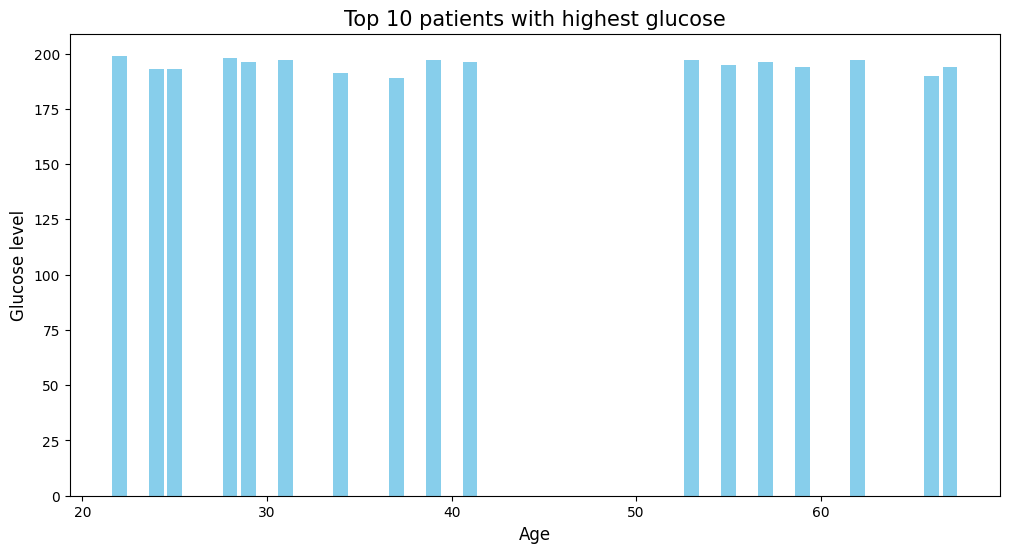

In [17]:
pima_sort = pima.sort_values(by='plas', ascending=False)
print(pima_sort.head(20))

x = pima_sort['age'][:20]        # hoặc dùng index
y = pima_sort['plas'][:20]       # Glucose

plt.figure(figsize=(12,6))
plt.bar(x, y, color="skyblue")
plt.title('Top 10 patients with highest glucose', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Glucose level', fontsize=12)
plt.show()


Biểu đồ cho thấy mức độ `Glucose(plas)` của từng bệnh nhân, từ đó có thể so sánh ai có mức GG` cao/thấp hơn.

### Dùng **Matplotlib** vẽ các biểu đồ *Histogram* cho từng thuộc tính

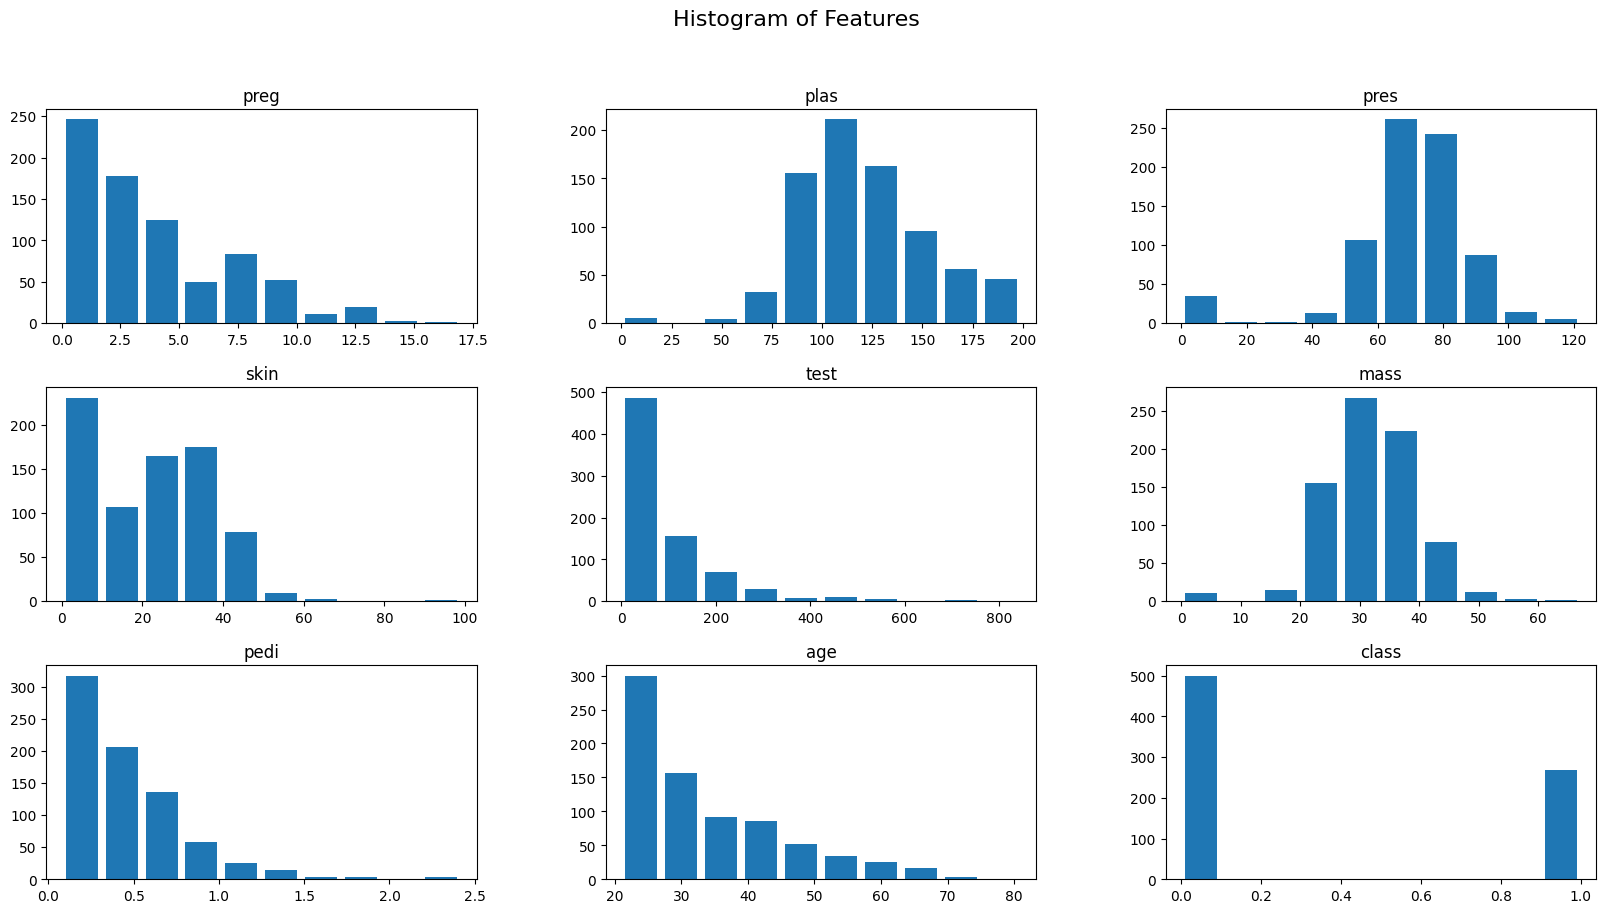

In [5]:
pima.hist(figsize=(20,10), grid=False, rwidth=0.8)
plt.suptitle("Histogram of Features", fontsize=16)
plt.show()

Biểu đồ **Histogram** được sử dụng để phân tích phân phối của từng biến **(univariate analysis)**. Nhờ tính trực quan, **Histogram** giúp quan sát nhanh đặc điểm dữ liệu, như xu hướng phân bố, độ tập trung, và sự xuất hiện của các giá trị ngoại lai.
Nhìn vào các biểu đồ trên ta có thể thấy cơ bản 1 số thứ:
&#8226;&nbsp;&nbsp; `preg`: số lần mang thai chủ yếu tập trung ở mức thấp (0–3 lần), ít người có trên 10 lần. Nhưng bên cạnh đó có 1 số người có đến 18(lệch khá lớn).<br>
&#8226;&nbsp;&nbsp; `plas` (glucose): phân bố gần chuẩn, tập trung nhiều trong khoảng 100–150.<br>
&#8226;&nbsp;&nbsp; `pres` (huyết áp): đa số bệnh nhân có huyết áp trong khoảng 60–80.<br>
&#8226;&nbsp;&nbsp; `skin` (độ dày da) và test (insulin test): phân phối lệch phải mạnh, nhiều giá trị bằng 0.<br>
&#8226;&nbsp;&nbsp; `mass` (BMI): tập trung quanh 30–35, gần giống phân phối chuẩn.<br>
&#8226;&nbsp;&nbsp; `pedi` (chỉ số phả hệ tiểu đường): phần lớn nhỏ hơn 1, chỉ vài trường hợp cao bất thường.<br>
&#8226;&nbsp;&nbsp; `age `: tập trung ở nhóm 20–40 tuổi, ít bệnh nhân lớn tuổi.<br>
&#8226;&nbsp;&nbsp; `class` (kết quả tiểu đường): dữ liệu nhị phân, cho thấy số người không mắc bệnh nhiều hơn người mắc bệnh.

### Dùng **Matplotlib** vẽ các biểu đồ **Box Plot**

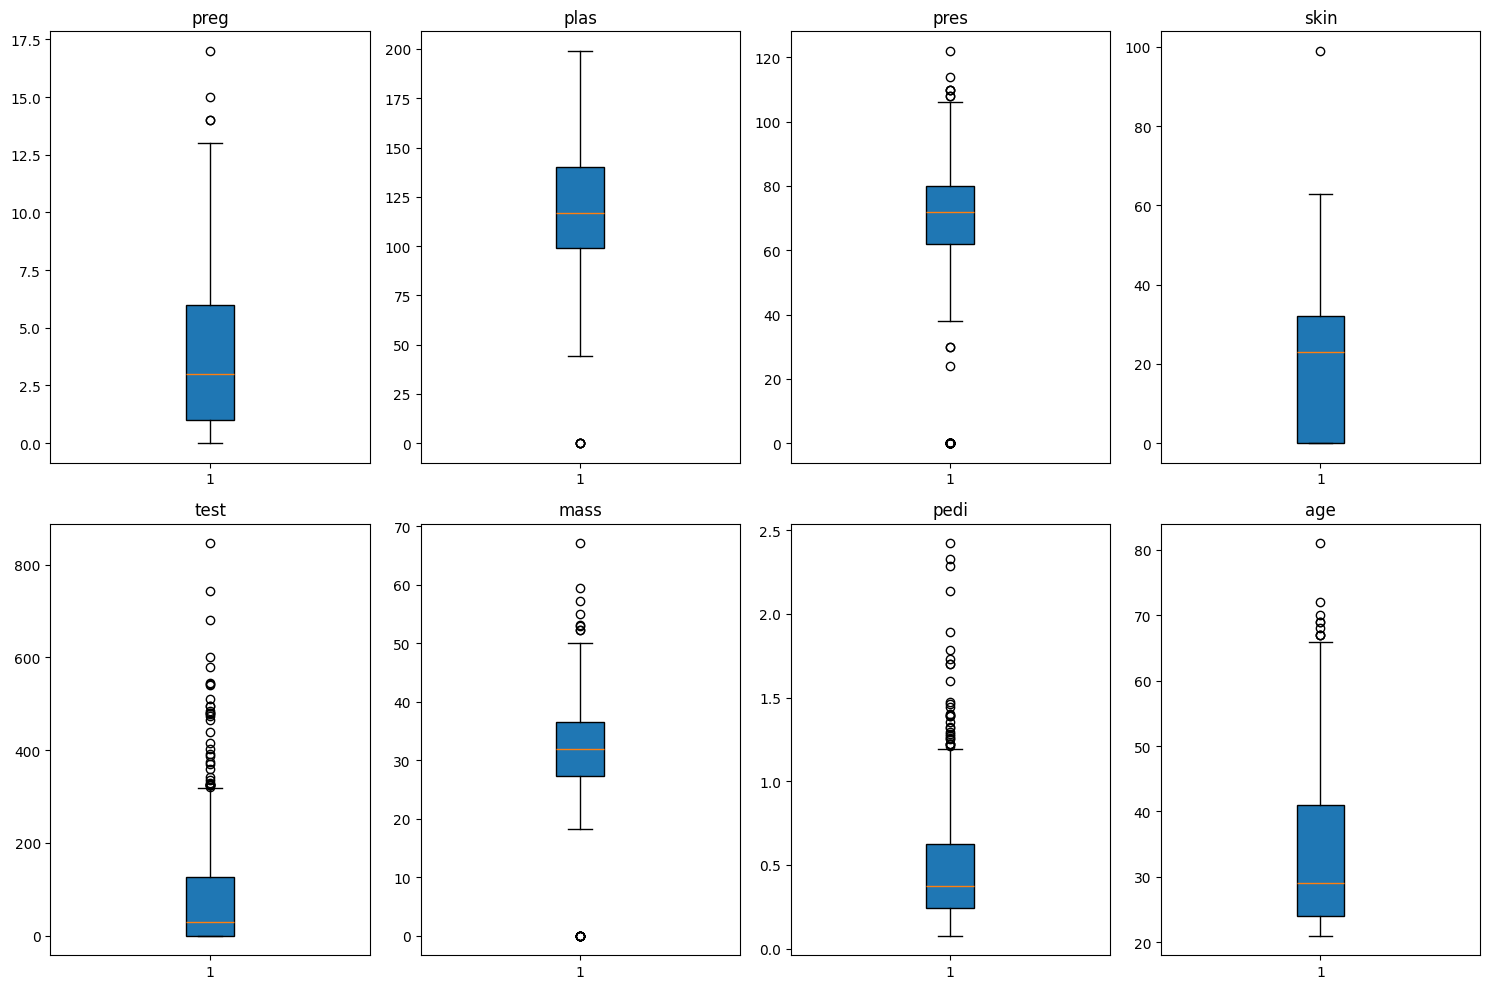

In [6]:
cols = pima.drop(columns=["class"]).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 4, i)   # 2 hàng, 4 cột (8 biến)
    plt.boxplot(pima[col], patch_artist=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Biểu đồ Box Plot thường dùng để mô tả phân phối dữ liệu và phát hiện các giá trị ngoại lai(outliers).<br>
Cụ thể mỗi Box Plot thể hiện:<br>
&#8226;&nbsp;&nbsp; *Đường giữa* (median - trung vị) : đường ngang trong hộp.<br>
&#8226;&nbsp;&nbsp; *Hộp* (box) : từ Q1 (25%) đến Q3(75%) &rarr; vùng phân vị giữa.<br>
&#8226;&nbsp;&nbsp; *Whiskers* (râu): khoảng giá trị trong phạm vi [Q1 – 1.5 * IQR, Q3 + 1.5 * IQR].<br>
&#8226;&nbsp;&nbsp; *Các điểm tròn*: giá trị ngoại lai (outliers).<br>

Từ hình trên có thể nhận thấy 1 vài điều:
&#8226;&nbsp;&nbsp; `preg` (số lần mang thai): phân phối lệch phải, nhiều giá trị thấp, một số ít bệnh nhân có trên 12–15 lần mang thai (ngoại lai).<br>
&#8226;&nbsp;&nbsp; `plas` (glucose): trung vị khoảng ~110, phần lớn nằm trong 100–150, có một số ngoại lai rất thấp (0) và cao (gần 200).<br>
&#8226;&nbsp;&nbsp; `pres` (huyết áp): trung vị khoảng 70, dữ liệu khá tập trung, nhưng có nhiều giá trị bất thường thấp (0) và cao trên 100.<br>
&#8226;&nbsp;&nbsp; `skin` (độ dày da): phân phối lệch, nhiều giá trị bằng 0 (ngoại lai hoặc dữ liệu thiếu).<br>
&#8226;&nbsp;&nbsp; `test` (insulin test): cực kỳ lệch phải, nhiều giá trị 0, một số ngoại lai rất lớn (trên 800).<br>
&#8226;&nbsp;&nbsp; `mass` (BMI): trung vị khoảng 30, phần lớn nằm trong 25–35, nhưng có nhiều ngoại lai (dưới 10 và trên 50).<br>
&#8226;&nbsp;&nbsp; `pedi` (diabetes pedigree): đa số nhỏ hơn 1, nhiều ngoại lai >2.<br>
&#8226;&nbsp;&nbsp; `age` (tuổi): trung vị khoảng 30, tập trung ở nhóm 20–40 tuổi, một số ngoại lai trên 70–80.

### Dùng **matplotlib** vẽ các biểu đồ **Scatter Plot**

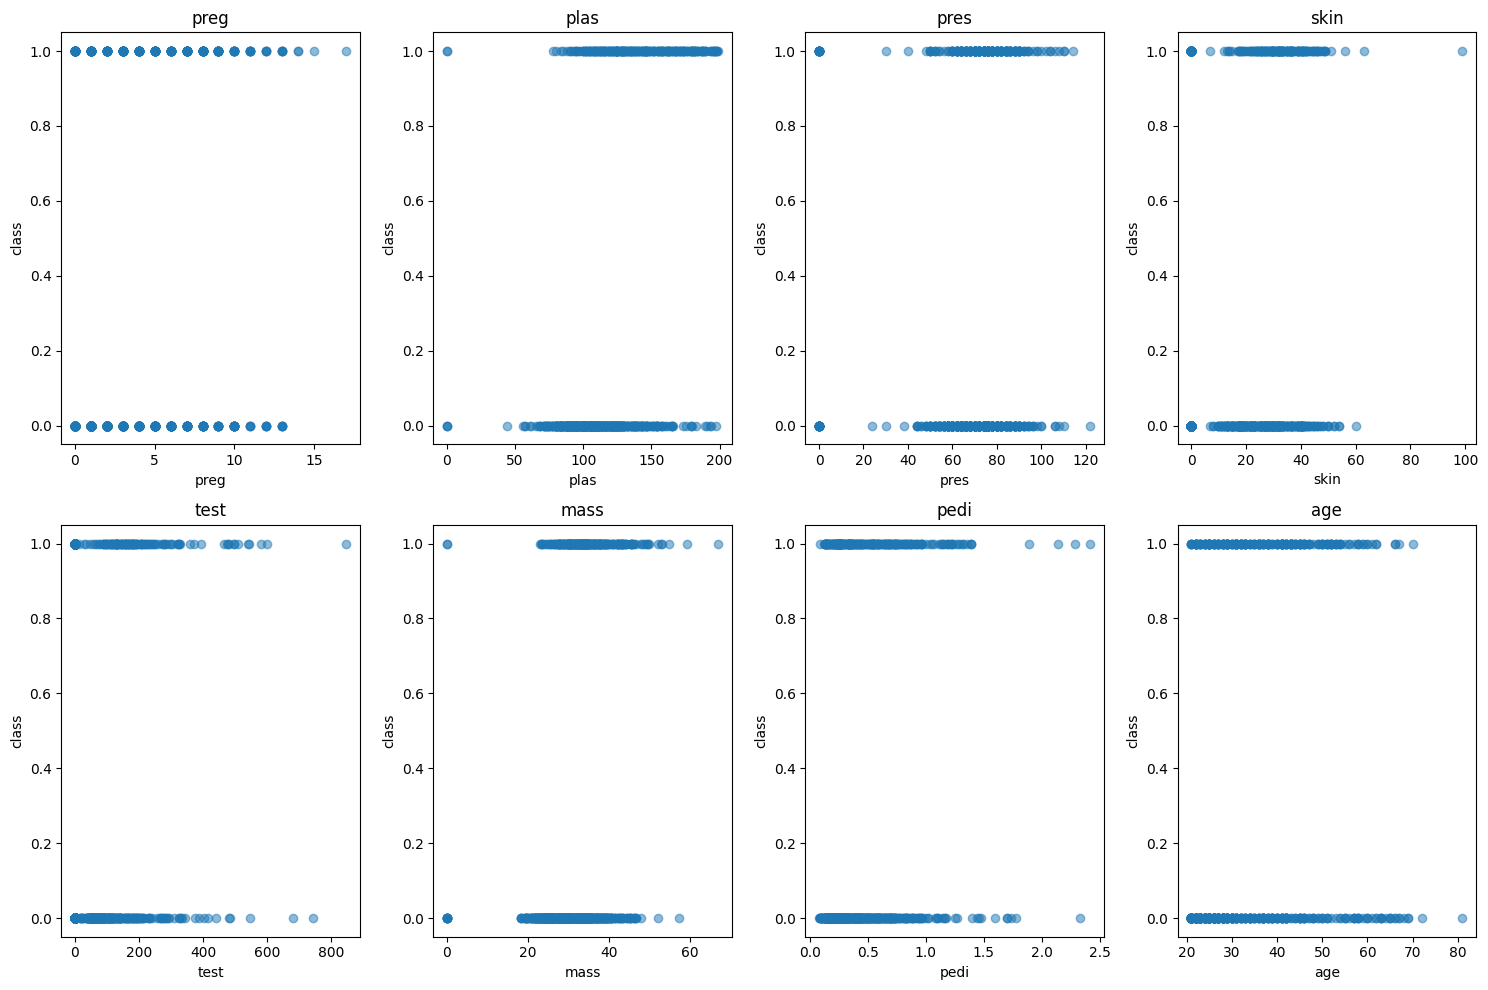

In [7]:

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 4, i)   # 2 hàng, 4 cột
    plt.scatter(pima[col], pima["class"], alpha=0.5)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("class")

plt.tight_layout()
plt.show()

Đây là biểu đồ phân tán dữ liệu theo một biến mục tiêu, các dấu chấm thể hiện sự phân tán. Dữ liệu tập trung càng nhiều thì có màu càng đậm và ngược lại.<br>
Ví dụ ở biểu đồ `plas`: <br>
&#8226;&nbsp;&nbsp; Dữ liệu plas thuộc class 1 chủ yếu từ 100 &rarr; 200.<br>
&#8226;&nbsp;&nbsp; Ngược lại, dữ liệu thuộc class 0 chủ yếu từ 60 &rarr; 150.

## Trực quan hóa dữ liệu với thư viện **Seaborn**

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

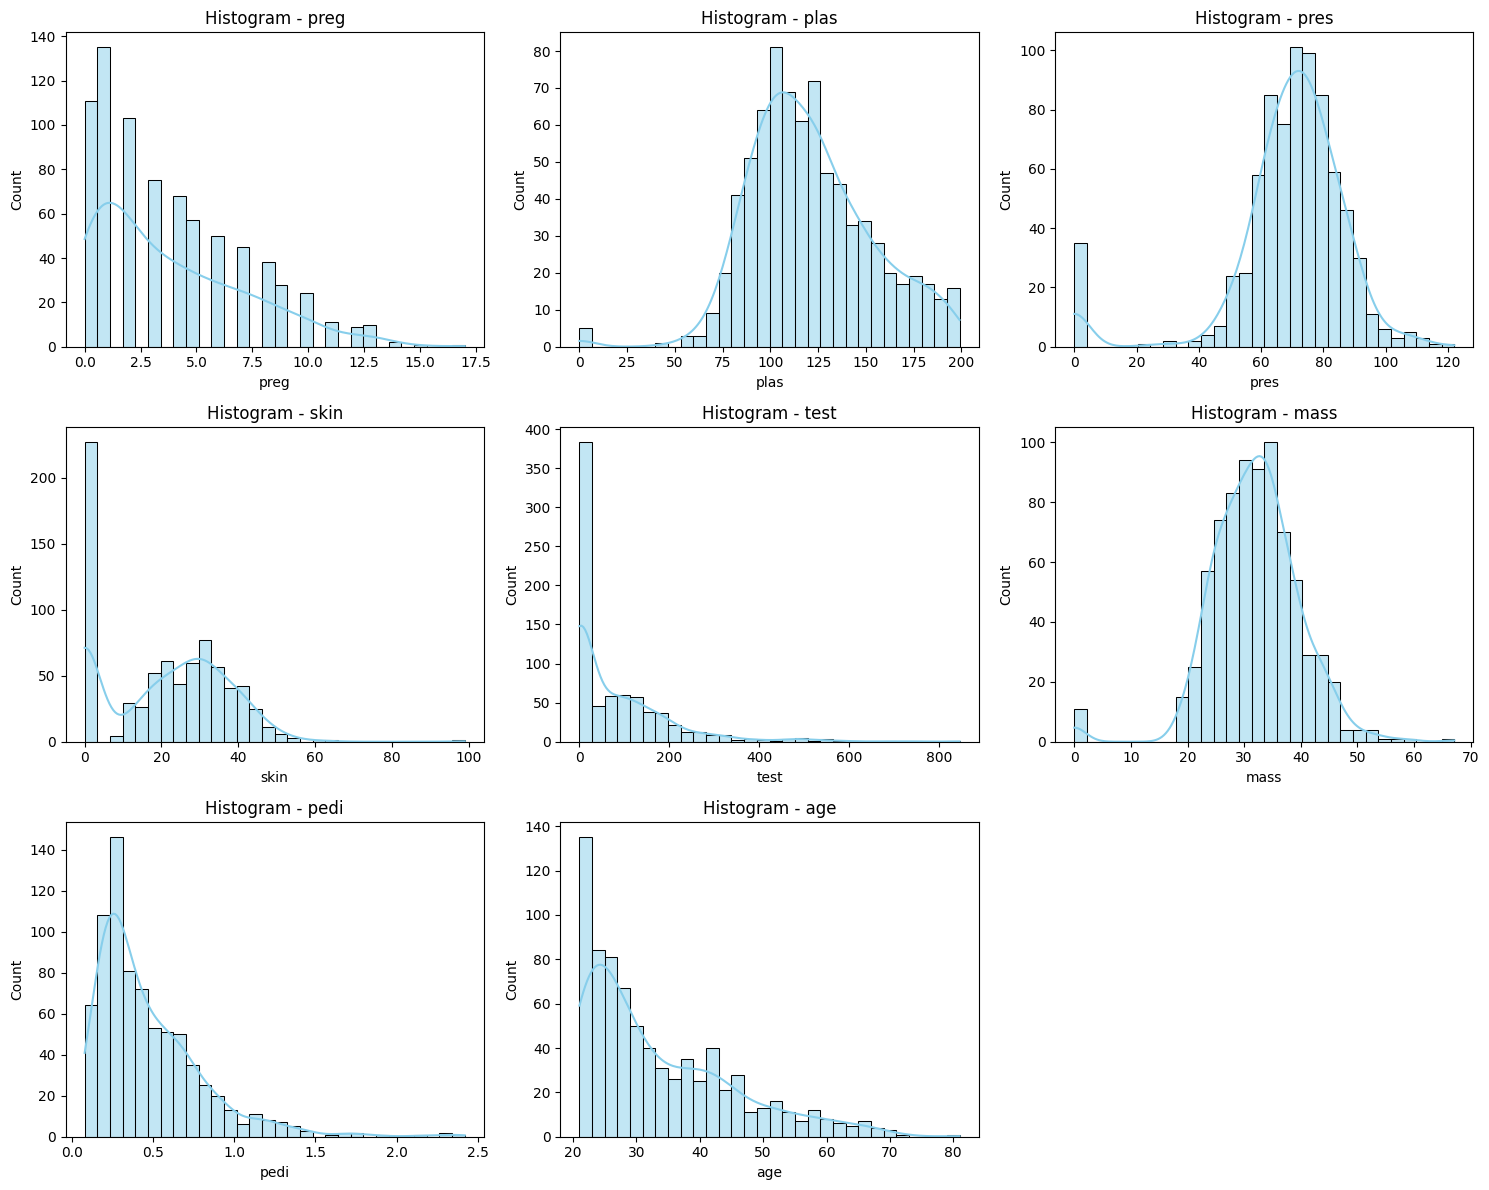

In [12]:
cols = [c for c in pima.columns if c != "class"]

plt.figure(figsize=(15, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)   # grid 3x3 (9 biến), thay đổi tùy số biến
    sns.histplot(pima[col], bins=30, kde=True, color="skyblue", line_kws={"color": "red"})
    plt.title(f"Histogram - {col}")

plt.tight_layout()
plt.show()

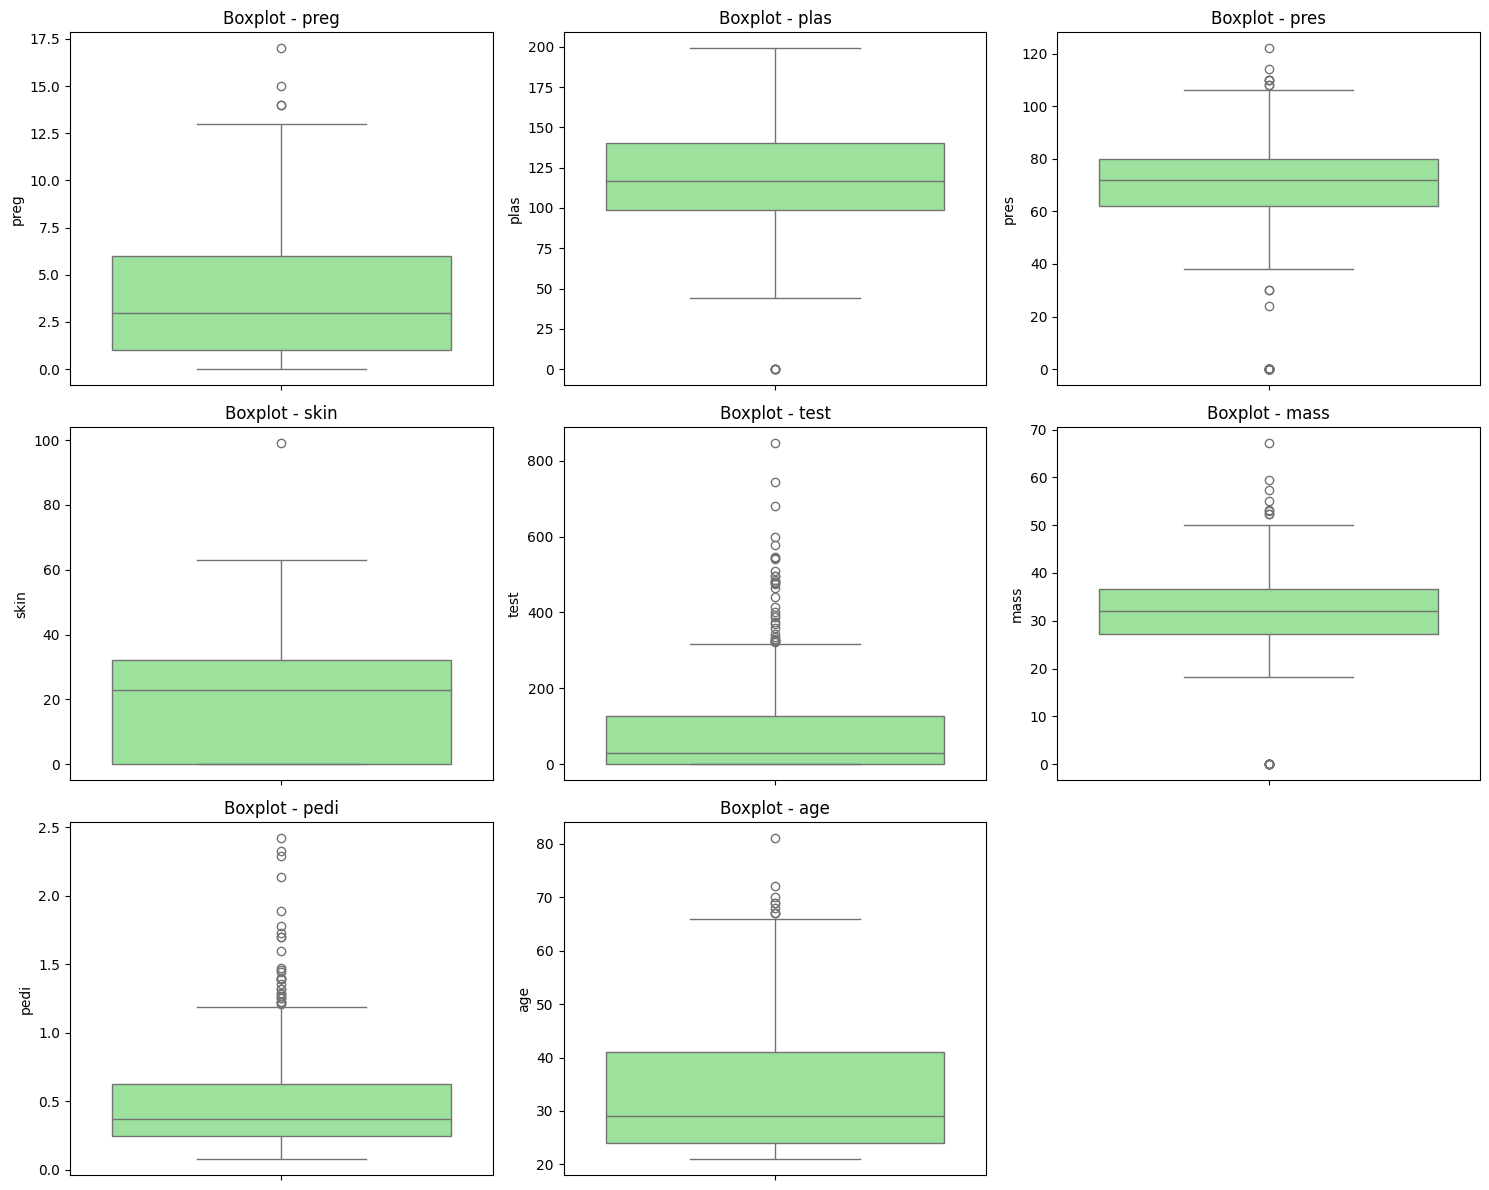

In [10]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=pima[col], color="lightgreen")
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()


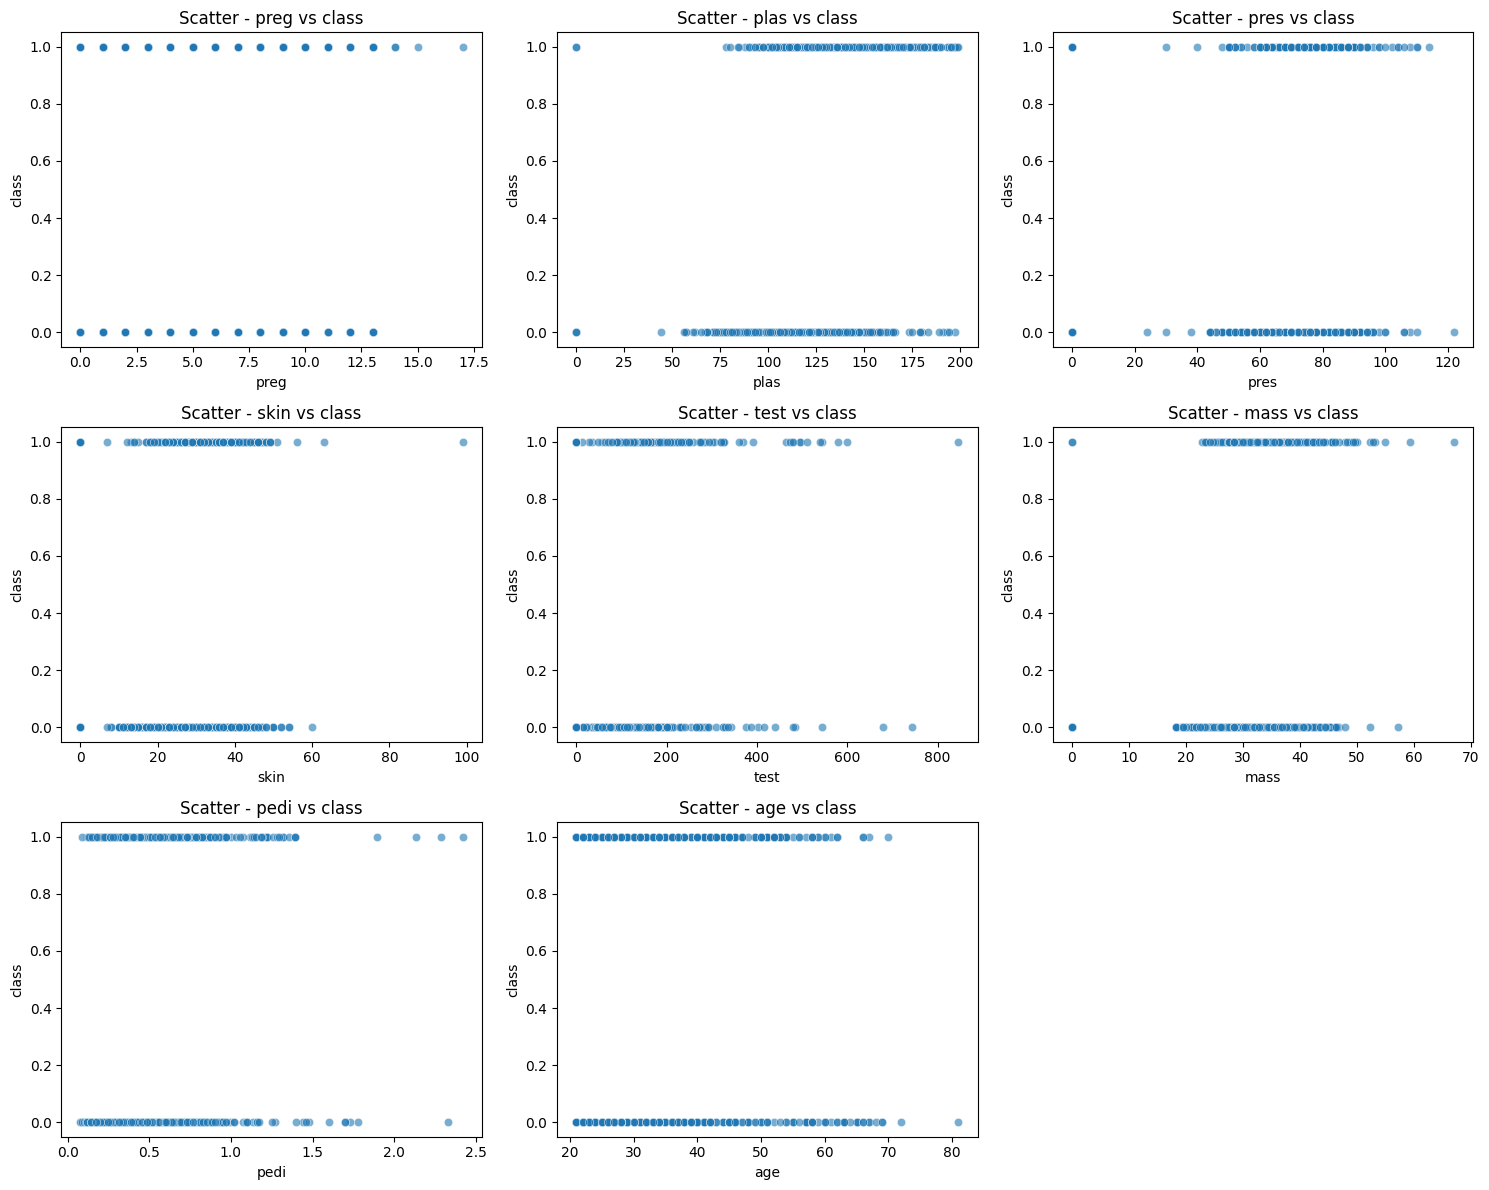

In [11]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=pima[col], y=pima["class"], alpha=0.6)
    plt.title(f"Scatter - {col} vs class")
    plt.xlabel(col)
    plt.ylabel("class")

plt.tight_layout()
plt.show()
